# Machine Learning for CICY 4-folds

Following the analysis in [arXiv:2007.13379](http://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](http://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds. The idea is to see whether the Inception network can also be applied in higher dimensions.

## PCA Analysis

In this notebook we consider the configuration matrices and study their principal components.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from mltools import *

ctx = Context(img_dir='img',
              log_dir='log',
              dat_dir='data',
              session='pca',
              subdir=False
             )
log = ctx.logger()

random_state = 123
np.random.seed(random_state)
tf.random.set_seed(random_state)

log.info('PCA analysis of the configuration matrix.')

## Read the Dataset

We read the dataset from its [URL](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_matrix.json.gz) and display basic information.

In [2]:
tab                  = Table('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_matrix.json.gz', ctx=ctx).read(orient='index')
df, (n_rows, n_cols) = tab.data()
log.debug(f'Dataset: {n_rows:d} rows X {n_cols:d} columns')

No. of rows:    905684.
No. of columns: 5.


We then save the shape of the matrix for future use:

In [3]:
shape = df['matrix'].apply(lambda m: np.shape(m)).max()
log.debug(f'Shape of the configuration matrix {shape}.')

## Reshape the Dataset

As the matrices are 2D arrays, we need to reshape them in order to have a full dataset $X \in \mathbb{N}^{n \times p}$, where $n$ is the number of CICY manifolds, and $p$ is the number of components of the largest configuration matrix.

In [4]:
matrix = df.eda.explode('matrix')

## PCA

We can finally apply the usual PCA.

In [5]:
dat = PCAnalysis(matrix)

We then plot the distribution of the eigenvalues:

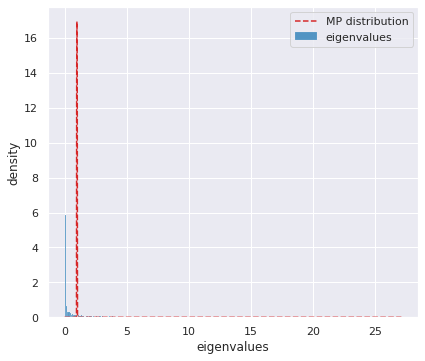

In [6]:
dat.distribution(binwidth=0.1, name='mp_distrib_matrix', save=True, ctx=ctx)

We can then select the eigenvectors whose eigenvalue is outside the limiting Marchenko-Pastur limiting distribution:

In [7]:
W = dat.eig_select()
W.shape

(320, 320)

However it seems that the PCA is inconclusive: all eigenvectors are necessary and the transformed data matrix $X' = X\, W$ would still have the same number of components.